# Genre Classification with Logistic Regression
Comparing three approaches: Baseline, Class-Balanced, and SMOTE

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt

## Load Dataset

In [2]:
print("Loading dataset...")
df = pd.read_csv("../../data/processed/final_dataset.csv")
print(f"Dataset shape: {df.shape}")
df.head()

Loading dataset...
Dataset shape: (685567, 15)


,track_name,artist_name,genre,danceability,energy,valence,acousticness,instrumentalness,liveness,speechiness,tempo,loudness,duration_sec,popularity,macro_genre
0,I Won't Give Up,Jason Mraz,acoustic,-0.295121,-1.244639,-1.178954,1.049226,-0.691216,-0.537222,-0.393524,0.403917,-0.189488,-0.062859,3.123384,Acoustic
1,93 Million Miles,Jason Mraz,acoustic,0.187328,-0.686411,0.221331,0.437937,-0.691179,-0.624753,-0.528338,0.631455,-0.229613,-0.221997,1.990284,Acoustic
2,Do Not Let Me Go,Joshua Hyslop,acoustic,-0.696259,-1.499723,-1.156609,0.046373,-0.691079,-0.664042,-0.477093,0.619702,-0.832373,-0.606319,2.430934,Acoustic
3,Fast Car,Boyce Avenue,acoustic,-0.788412,-1.436876,0.195262,1.367548,-0.691216,-0.712781,-0.445557,2.806734,-0.152002,0.366301,2.493884,Acoustic
4,Sky's Still Blue,Andrew Belle,acoustic,-0.582422,0.559434,-0.888469,-0.701259,-0.638350,-0.562088,-0.493649,1.695337,0.626921,-0.035059,2.242084,Acoustic


## Data Preprocessing

In [3]:
# Define features & target
feature_cols = [
    'danceability', 'energy', 'valence', 'acousticness', 'instrumentalness',
    'liveness', 'speechiness', 'tempo', 'loudness'
]

keep_genres = ['Acoustic', 'Electronic', 'Hip-Hop', 'Latin', 'Metal']
df = df[df['macro_genre'].isin(keep_genres)]
print(f"Filtered dataset size: {len(df)}")

X = df[feature_cols].values
y = df['macro_genre'].values

Filtered dataset size: 685567


## Check Class Distribution

In [4]:
unique, counts = np.unique(y, return_counts=True)
print("Class distribution:")
for genre, count in zip(unique, counts):
    print(f"{genre}: {count} samples ({count/len(y)*100:.1f}%)")

Class distribution:
Acoustic: 163542 samples (23.9%)
Electronic: 235768 samples (34.4%)
Hip-Hop: 26988 samples (3.9%)
Latin: 107272 samples (15.6%)
Metal: 151997 samples (22.2%)


## Train/Test Split

In [5]:
n = len(X)
idx = np.arange(n)
np.random.seed(42)
np.random.shuffle(idx)

split = int(0.8 * n)
train_idx, test_idx = idx[:split], idx[split:]

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")

Training set size: 548453
Test set size: 137114


## Feature Scaling

In [6]:
print("Scaling features...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Scaling complete!")

Scaling features...
Scaling complete!


## 1. Baseline Logistic Regression

In [7]:
print("=" * 60)
print("Training Baseline Logistic Regression")
print("=" * 60)

lr_baseline = LogisticRegression(max_iter=200, random_state=42)
lr_baseline.fit(X_train_scaled, y_train)
print("Training complete!")

Training Baseline Logistic Regression
Training complete!


In [8]:
# Evaluate Baseline
y_pred_baseline = lr_baseline.predict(X_test_scaled)
acc_baseline = accuracy_score(y_test, y_pred_baseline)
f1_baseline = f1_score(y_test, y_pred_baseline, average='macro')

print(f"\n{'Baseline Logistic Regression Results':^60}")
print("=" * 60)
print(f"Accuracy: {acc_baseline:.2%}")
print(f"F1 Score (macro): {f1_baseline:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_baseline))


            Baseline Logistic Regression Results            
Accuracy: 70.04%
F1 Score (macro): 0.5824

Classification Report:
              precision    recall  f1-score   support

    Acoustic       0.80      0.73      0.76     32730
  Electronic       0.66      0.77      0.71     47171
     Hip-Hop       0.31      0.04      0.07      5288
       Latin       0.68      0.67      0.68     21562
       Metal       0.69      0.70      0.69     30363

    accuracy                           0.70    137114
   macro avg       0.63      0.58      0.58    137114
weighted avg       0.69      0.70      0.69    137114



## 2. Class-Balanced Logistic Regression

In [9]:
print("\n" + "=" * 60)
print("Training Class-Balanced Logistic Regression")
print("=" * 60)

lr_balanced = LogisticRegression(max_iter=200, random_state=42, class_weight='balanced')
lr_balanced.fit(X_train_scaled, y_train)
print("Training complete!")


Training Class-Balanced Logistic Regression
Training complete!


In [10]:
# Evaluate Class-Balanced
y_pred_balanced = lr_balanced.predict(X_test_scaled)
acc_balanced = accuracy_score(y_test, y_pred_balanced)
f1_balanced = f1_score(y_test, y_pred_balanced, average='macro')

print(f"\n{'Class-Balanced Logistic Regression Results':^60}")
print("=" * 60)
print(f"Accuracy: {acc_balanced:.2%}")
print(f"F1 Score (macro): {f1_balanced:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_balanced))


         Class-Balanced Logistic Regression Results         
Accuracy: 65.73%
F1 Score (macro): 0.6065

Classification Report:
              precision    recall  f1-score   support

    Acoustic       0.82      0.70      0.75     32730
  Electronic       0.78      0.53      0.63     47171
     Hip-Hop       0.17      0.51      0.26      5288
       Latin       0.61      0.75      0.67     21562
       Metal       0.66      0.77      0.71     30363

    accuracy                           0.66    137114
   macro avg       0.61      0.65      0.61    137114
weighted avg       0.71      0.66      0.67    137114



## 3. SMOTE Logistic Regression

In [11]:
print("\n" + "=" * 60)
print("Training SMOTE Logistic Regression")
print("=" * 60)

print("Applying SMOTE to balance training classes...")
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print(f"Original training size: {X_train_scaled.shape[0]}")
print(f"Resampled training size: {X_train_resampled.shape[0]}")

lr_smote = LogisticRegression(max_iter=200, random_state=42)
lr_smote.fit(X_train_resampled, y_train_resampled)
print("Training complete!")


Training SMOTE Logistic Regression
Applying SMOTE to balance training classes...
Original training size: 548453
Resampled training size: 942985
Training complete!


In [12]:
# Evaluate SMOTE
y_pred_smote = lr_smote.predict(X_test_scaled)
acc_smote = accuracy_score(y_test, y_pred_smote)
f1_smote = f1_score(y_test, y_pred_smote, average='macro')

print(f"\n{'SMOTE Logistic Regression Results':^60}")
print("=" * 60)
print(f"Accuracy: {acc_smote:.2%}")
print(f"F1 Score (macro): {f1_smote:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_smote))


             SMOTE Logistic Regression Results              
Accuracy: 65.54%
F1 Score (macro): 0.6052

Classification Report:
              precision    recall  f1-score   support

    Acoustic       0.82      0.70      0.75     32730
  Electronic       0.78      0.53      0.63     47171
     Hip-Hop       0.17      0.52      0.26      5288
       Latin       0.61      0.75      0.67     21562
       Metal       0.66      0.77      0.71     30363

    accuracy                           0.66    137114
   macro avg       0.61      0.65      0.61    137114
weighted avg       0.71      0.66      0.67    137114



## Compare All Three Approaches


COMPARISON SUMMARY
         Approach  Accuracy  F1 Score (macro)
      Baseline LR  0.700439          0.582376
Class-Balanced LR  0.657271          0.606460
         SMOTE LR  0.655352          0.605196


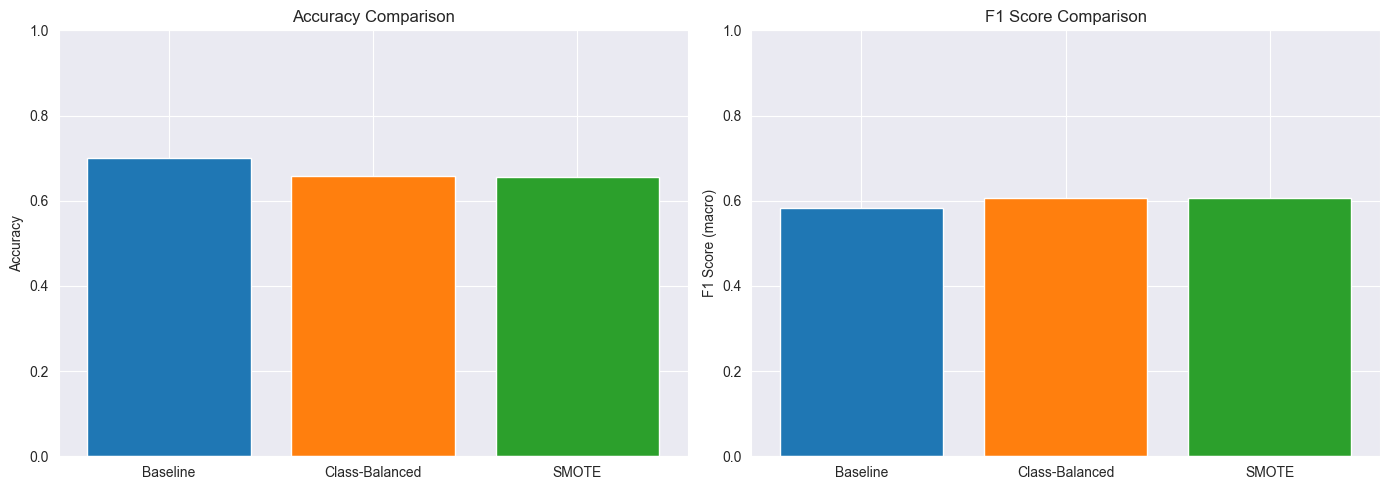

In [13]:
# Summary comparison
print("\n" + "=" * 60)
print("COMPARISON SUMMARY")
print("=" * 60)

comparison_df = pd.DataFrame({
    'Approach': ['Baseline LR', 'Class-Balanced LR', 'SMOTE LR'],
    'Accuracy': [acc_baseline, acc_balanced, acc_smote],
    'F1 Score (macro)': [f1_baseline, f1_balanced, f1_smote]
})

print(comparison_df.to_string(index=False))

# Bar chart comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

approaches = ['Baseline', 'Class-Balanced', 'SMOTE']
accuracies = [acc_baseline, acc_balanced, acc_smote]
f1_scores = [f1_baseline, f1_balanced, f1_smote]

axes[0].bar(approaches, accuracies, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Accuracy Comparison')
axes[0].set_ylim([0, 1])

axes[1].bar(approaches, f1_scores, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
axes[1].set_ylabel('F1 Score (macro)')
axes[1].set_title('F1 Score Comparison')
axes[1].set_ylim([0, 1])

plt.tight_layout()
plt.savefig('lr_comparison.png', dpi=300)
plt.show()

## Confusion Matrices

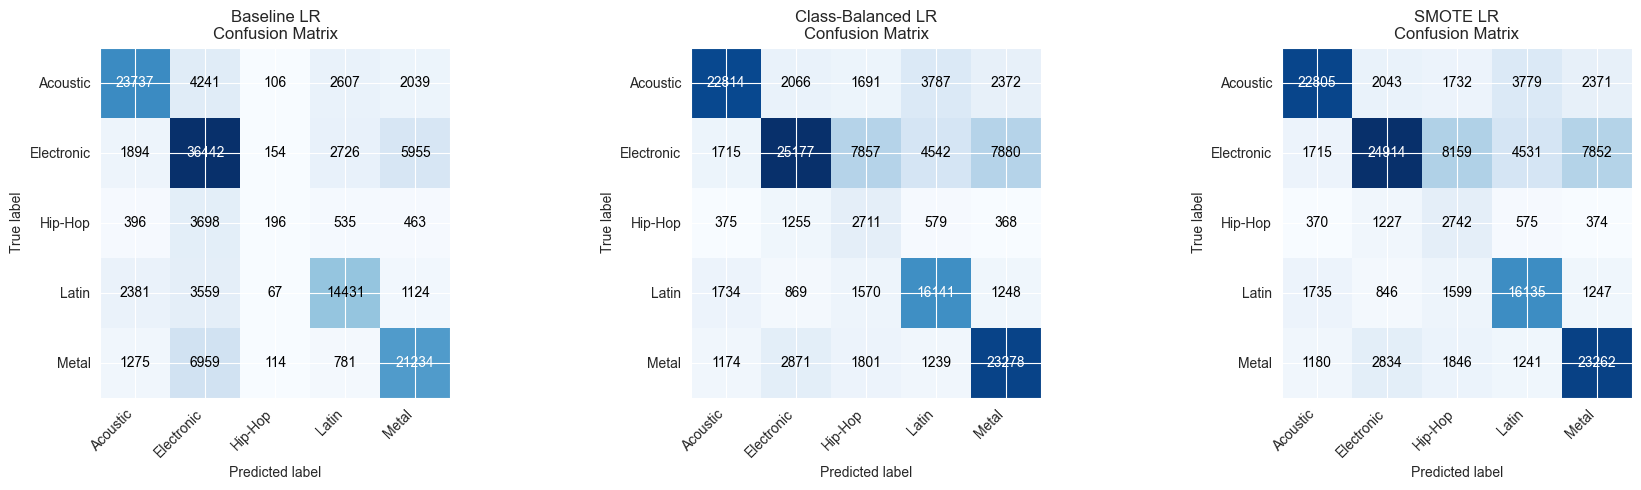

In [14]:
# Create confusion matrices for all three approaches
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models = [
    ('Baseline LR', y_pred_baseline),
    ('Class-Balanced LR', y_pred_balanced),
    ('SMOTE LR', y_pred_smote)
]

for idx, (title, y_pred) in enumerate(models):
    cm = confusion_matrix(y_test, y_pred, labels=keep_genres)
    
    im = axes[idx].imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    axes[idx].set_title(f'{title}\nConfusion Matrix')
    
    tick_marks = np.arange(len(keep_genres))
    axes[idx].set_xticks(tick_marks)
    axes[idx].set_xticklabels(keep_genres, rotation=45, ha='right')
    axes[idx].set_yticks(tick_marks)
    axes[idx].set_yticklabels(keep_genres)
    
    # Add text annotations
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            axes[idx].text(j, i, format(cm[i, j], 'd'),
                          ha="center", va="center",
                          color="white" if cm[i, j] > thresh else "black")
    
    axes[idx].set_ylabel('True label')
    axes[idx].set_xlabel('Predicted label')

plt.tight_layout()
plt.savefig('lr_confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()